In [42]:
import pandas as pd
df = pd.read_csv("san_train.csv")
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [43]:
df.shape

(200000, 202)

In [44]:
from sklearn.model_selection import train_test_split
X = df.drop(["ID_code", "target"], axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [46]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization

model = tf.keras.Sequential([
    Input(shape=(200,)),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

In [47]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

In [48]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode="max"
)

In [49]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=256,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - auc: 0.6531 - loss: 0.5060 - val_auc: 0.8490 - val_loss: 0.2373
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8291 - loss: 0.2533 - val_auc: 0.8550 - val_loss: 0.2341
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.8504 - loss: 0.2376 - val_auc: 0.8567 - val_loss: 0.2327
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8607 - loss: 0.2315 - val_auc: 0.8569 - val_loss: 0.2328
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8639 - loss: 0.2288 - val_auc: 0.8570 - val_loss: 0.2331
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - auc: 0.8716 - loss: 0.2251 - val_auc: 0.8587 - val_loss: 0.2316
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.8730 - loss: 0.2247 - val_auc: 0.8583 - val_loss: 0.2323
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8783 - loss: 0.2212 - val_auc: 0.8581 - val_loss: 0.2325
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - a

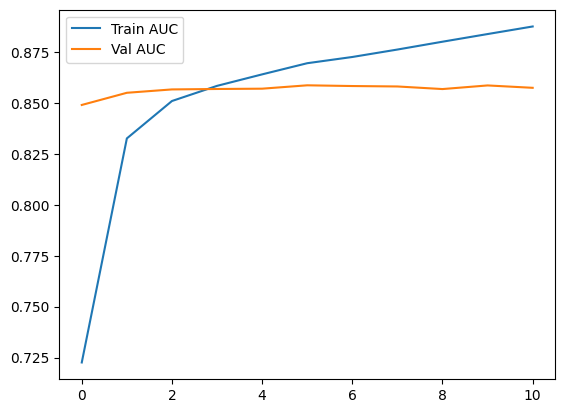

In [53]:
import matplotlib.pyplot as plt
plt.plot(history.history['auc'], label="Train AUC")
plt.plot(history.history['val_auc'], label="Val AUC")
plt.legend()
plt.show()

In [51]:
from sklearn.metrics import roc_auc_score
y_pred = model.predict(X_test).ravel() #ravel to convert multidimensional array to 1-D array
auc_score = roc_auc_score(y_test, y_pred)
auc_score

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


np.float64(0.8588784157312382)

Text(50.722222222222214, 0.5, 'Truth')

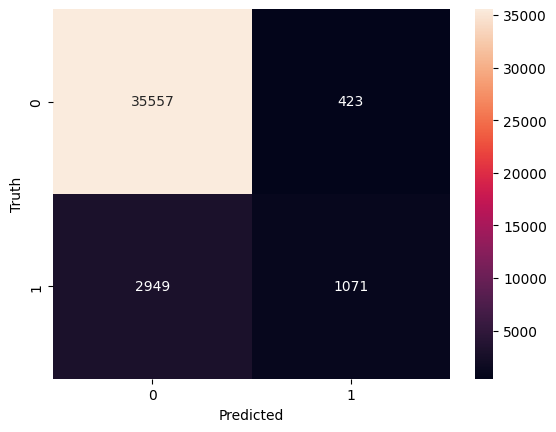

In [56]:
import seaborn as sns
y_pred_class = (y_pred > 0.5).astype(int)
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_pred_class)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [57]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     35980
           1       0.72      0.27      0.39      4020

    accuracy                           0.92     40000
   macro avg       0.82      0.63      0.67     40000
weighted avg       0.90      0.92      0.90     40000

